In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [1]:
from google.colab import drive
drive.mount('/content/drive')
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

Mounted at /content/drive


Device: cpu
Found all 40 images.
Input tensor shape:  (20, 3, 128, 128)
Target tensor shape: (20, 3, 128, 128)
Epoch 001/100 | MSE: 0.052558
Epoch 002/100 | MSE: 0.053405
Epoch 003/100 | MSE: 0.051526
Epoch 004/100 | MSE: 0.050969
Epoch 005/100 | MSE: 0.049962
Epoch 006/100 | MSE: 0.049840
Epoch 007/100 | MSE: 0.048718
Epoch 008/100 | MSE: 0.048358
Epoch 009/100 | MSE: 0.047848
Epoch 010/100 | MSE: 0.047771
Epoch 011/100 | MSE: 0.047099
Epoch 012/100 | MSE: 0.046902
Epoch 013/100 | MSE: 0.046314
Epoch 014/100 | MSE: 0.045889
Epoch 015/100 | MSE: 0.045218
Epoch 016/100 | MSE: 0.044177
Epoch 017/100 | MSE: 0.042982
Epoch 018/100 | MSE: 0.041529
Epoch 019/100 | MSE: 0.039561
Epoch 020/100 | MSE: 0.036550
Epoch 021/100 | MSE: 0.034377
Epoch 022/100 | MSE: 0.032317
Epoch 023/100 | MSE: 0.029999
Epoch 024/100 | MSE: 0.026399
Epoch 025/100 | MSE: 0.024853
Epoch 026/100 | MSE: 0.022635
Epoch 027/100 | MSE: 0.020875
Epoch 028/100 | MSE: 0.019404
Epoch 029/100 | MSE: 0.017957
Epoch 030/100 | MSE

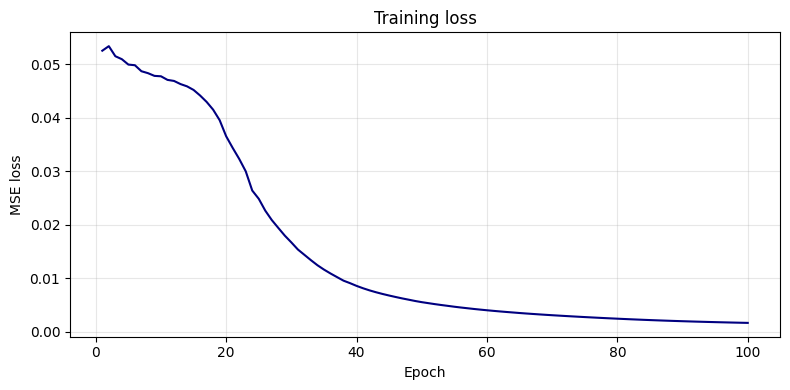

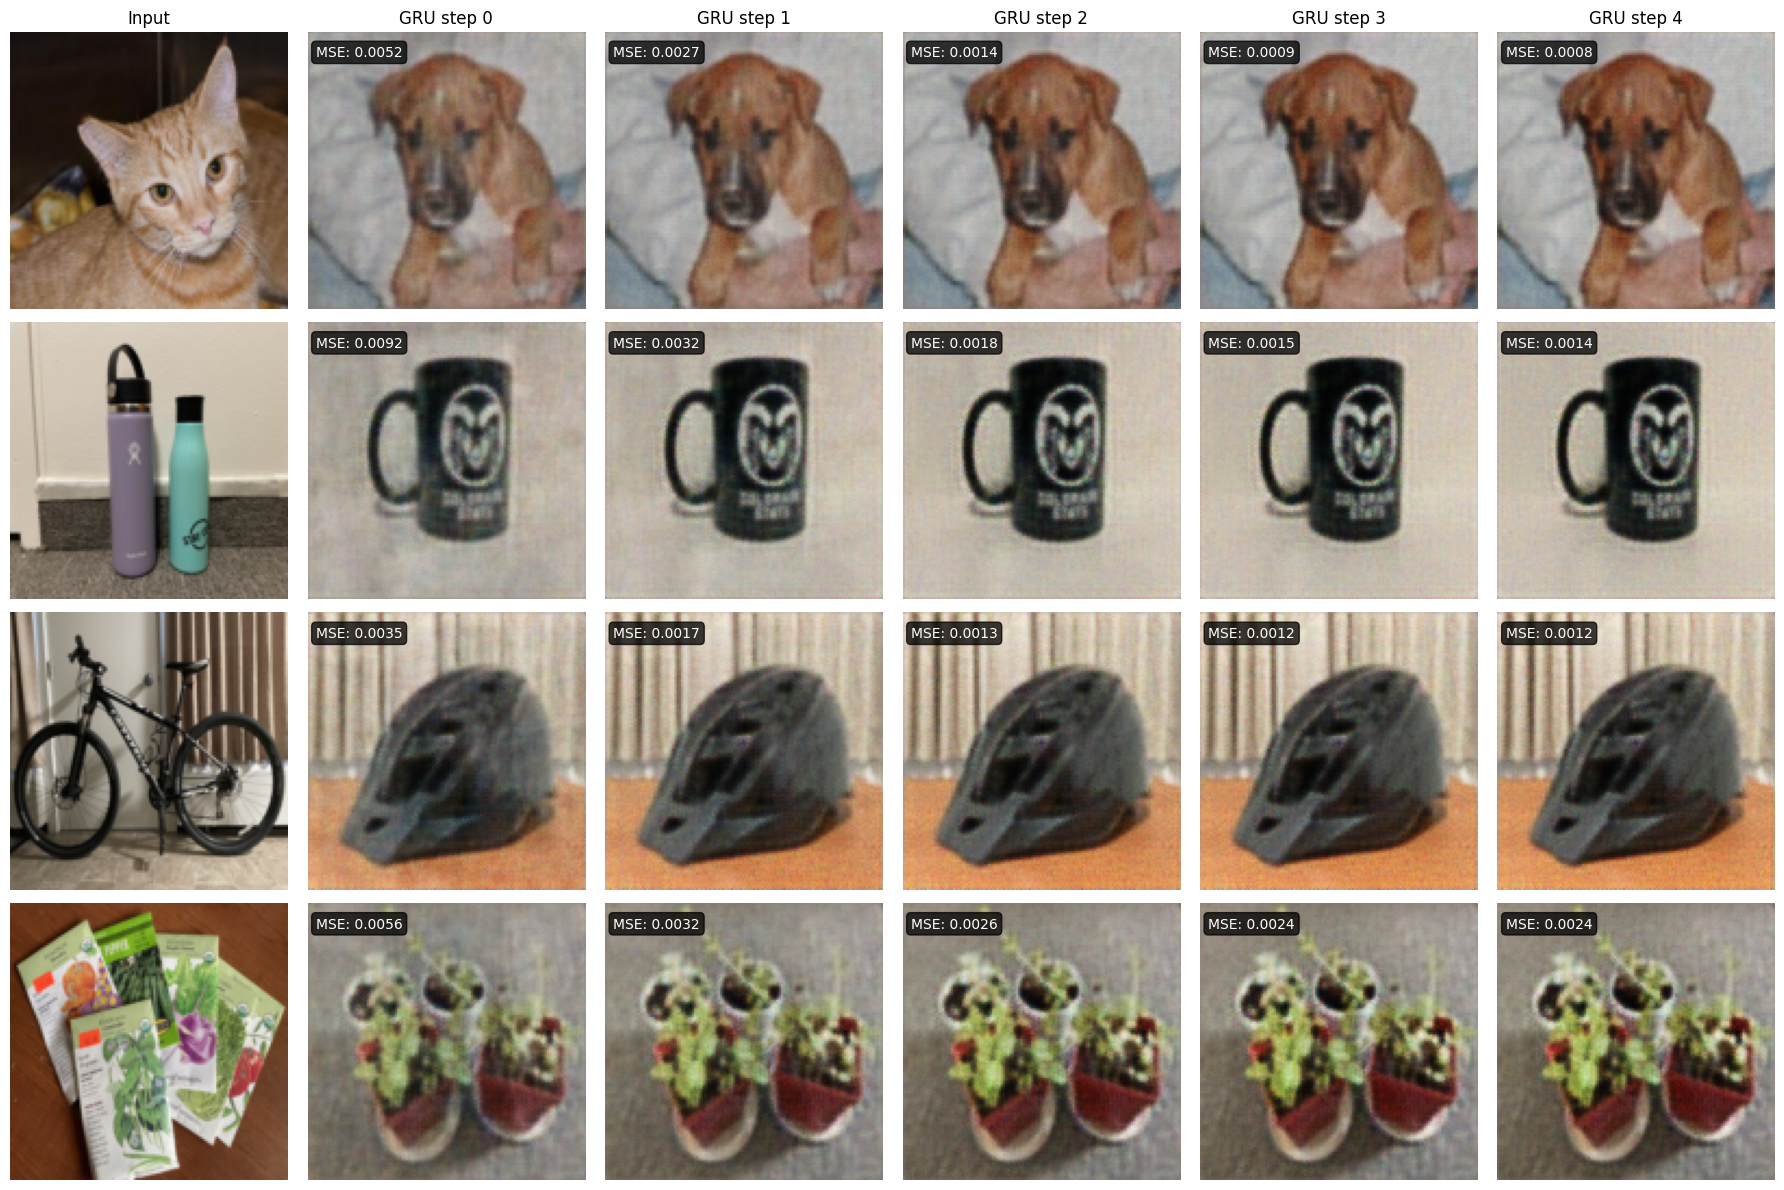

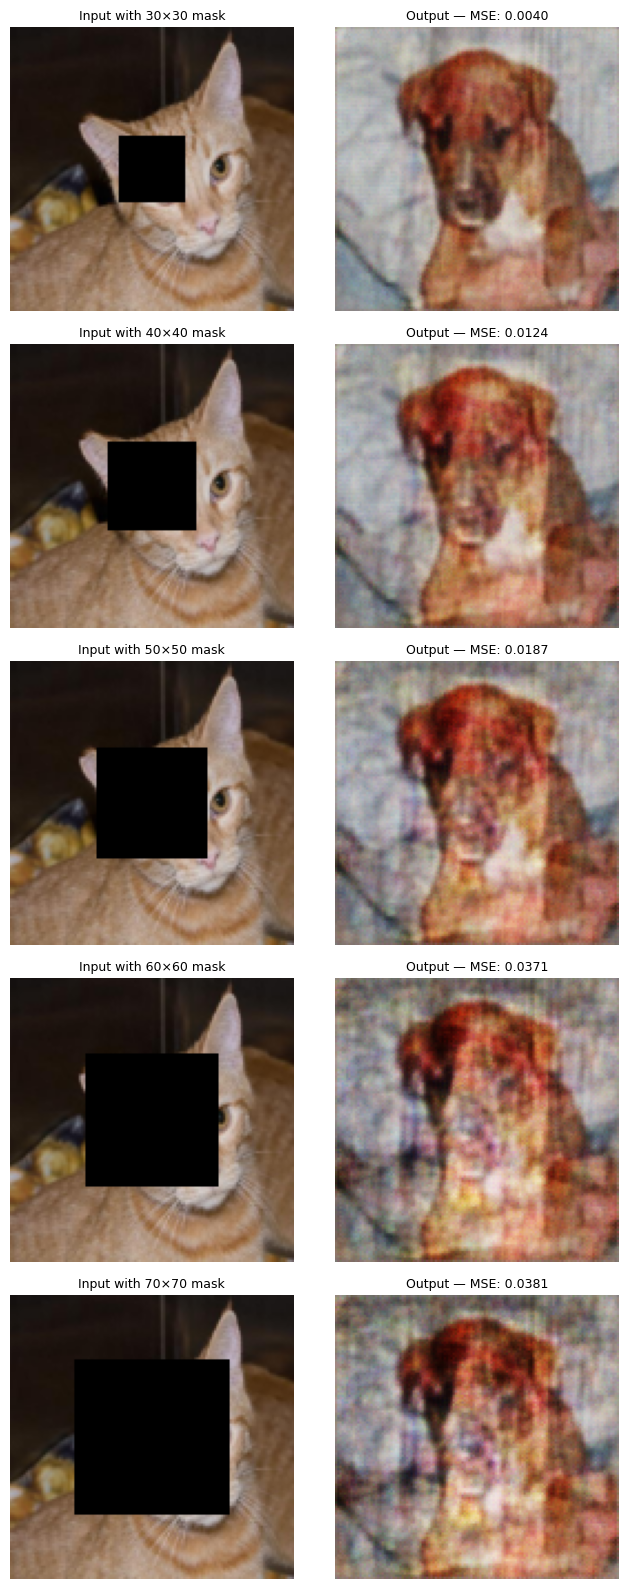

In [6]:
# ============================================================
# Imports and setup
# ============================================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms


# Select the best available device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

# Reproducibility
seed = 1002
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


# ============================================================
# Image paths
# ============================================================
workpath = "/content/drive/MyDrive/DigitalImageProcessing/"
image_folder = os.path.join(workpath, "Data", "AM_Data")

input_images = [
    "cat_1.JPG",
    "laptop_1.JPG",
    "badminton_bat_1.JPG",
    "water_bottle_1.JPG",
    "acralic_paints_1.JPG",
    "cycle_1.JPG",
    "lotion_1_1.JPG",
    "spread_1.JPG",
    "corn_flakes_1.JPG",
    "lemon_1.JPG",
    "rice_1.JPG",
    "suger_1.JPG",
    "onions_1.JPG",
    "seeds_1.JPG",
    "tide_1.JPG",
    "board_1.JPG",
    "shoes_1.JPG",
    "bag_1_1.JPG",
    "colgate_1.JPG",
    "comb_1.JPG",
]

output_images = [
    "dog_1.JPG",
    "books_1.JPG",
    "badminton_court_1.JPG",
    "tea_cup_1.JPG",
    "paint_breshes_1.JPG",
    "helmet_1.JPG",
    "lotion_2_1.JPG",
    "bread_1.JPG",
    "milk_1.JPG",
    "stoberry_1.JPG",
    "flour_1.JPG",
    "salt_1.JPG",
    "garlic_1.JPG",
    "plants_1.JPG",
    "tide_orange_1.JPG",
    "board_pens_1.JPG",
    "flats_1.JPG",
    "bag_2_1.JPG",
    "brush_1.JPG",
    "bands_1.JPG",
]

assert len(input_images) == len(output_images), (
    "Input and output lists must contain the same number of images."
)

assert os.path.isdir(image_folder), (
    f"Image folder does not exist: {image_folder}"
)

# Check all files before attempting to load them
missing_files = [
    filename
    for filename in input_images + output_images
    if not os.path.isfile(os.path.join(image_folder, filename))
]

assert not missing_files, (
    "The following images are missing:\n" + "\n".join(missing_files)
)

print(f"Found all {len(input_images) + len(output_images)} images.")


# ============================================================
# Load and preprocess images
# ============================================================
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


def load_images(image_names):
    """Load a list of images as normalized RGB tensors."""
    tensors = []

    for image_name in image_names:
        image_path = os.path.join(image_folder, image_name)

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            tensors.append(transform(image))

    return torch.stack(tensors)


X = load_images(input_images).to(device)
Y = load_images(output_images).to(device)

print("Input tensor shape: ", tuple(X.shape))
print("Target tensor shape:", tuple(Y.shape))


# ============================================================
# Feedback auto-associative network
# ============================================================
class FeedbackAutoAssocNet(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.latent_dim = latent_dim

        # Input: (B, 3, 128, 128)
        self.encoder = nn.Sequential(
            nn.Conv2d(
                3, 32,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),

            # (B, 32, 64, 64)
            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),

            # (B, 64, 32, 32)
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, latent_dim),
        )

        self.rnn = nn.GRU(
            input_size=latent_dim,
            hidden_size=latent_dim,
            batch_first=True,
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 32 * 32),
            nn.ReLU(),

            nn.Unflatten(1, (64, 32, 32)),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.Sigmoid(),
        )

    def forward(
        self,
        x,
        hidden_state=None,
        max_steps=5,
        return_latents=False,
    ):
        initial_z = self.encoder(x)
        z = initial_z
        hidden = hidden_state
        latent_steps = [z]

        for _ in range(max_steps):
            z_output, hidden = self.rnn(
                z.unsqueeze(1),
                hidden,
            )

            # Preserve input-specific information
            z = initial_z + z_output.squeeze(1)
            latent_steps.append(z)

        output_image = self.decoder(z)

        if return_latents:
            return (
                output_image,
                hidden,
                initial_z,
                z,
                latent_steps,
            )

        return output_image, hidden


# ============================================================
# Create and train model
# ============================================================
model = FeedbackAutoAssocNet(latent_dim=256).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

num_epochs = 100
losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Use a fresh hidden state for each epoch
    output, _ = model(X)

    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(
        f"Epoch {epoch + 1:03d}/{num_epochs} | "
        f"MSE: {loss.item():.6f}"
    )


# ============================================================
# Display training loss
# ============================================================
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, num_epochs + 1),
    losses,
    color="navy",
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Display decoder outputs at selected GRU steps
# ============================================================
sample_indices = [0, 3, 5, 13]

sample_inputs = [X[index] for index in sample_indices]
sample_targets = [Y[index] for index in sample_indices]

model.eval()

with torch.no_grad():
    _, _, _, _, first_latent_steps = model(
        sample_inputs[0].unsqueeze(0),
        return_latents=True,
    )

total_steps = len(first_latent_steps)

# First five steps, then every 30 steps starting at step 10
step_indices = list(range(min(5, total_steps)))
step_indices += list(range(10, total_steps, 30))
step_indices = sorted(set(step_indices))

number_of_rows = len(sample_inputs)
number_of_columns = len(step_indices) + 1

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(3 * number_of_columns, 3 * number_of_rows),
    squeeze=False,
)

for row, (input_tensor, target_tensor) in enumerate(
    zip(sample_inputs, sample_targets)
):
    with torch.no_grad():
        _, _, _, _, latent_steps = model(
            input_tensor.unsqueeze(0),
            return_latents=True,
        )

    # Input image
    axes[row, 0].imshow(
        input_tensor
        .detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    axes[row, 0].axis("off")

    if row == 0:
        axes[row, 0].set_title("Input")

    # Outputs decoded from the selected latent steps
    for column, step in enumerate(step_indices, start=1):
        axes[row, column].axis("off")

        if step >= len(latent_steps):
            continue

        with torch.no_grad():
            decoded = model.decoder(latent_steps[step])
            step_loss = criterion(
                decoded,
                target_tensor.unsqueeze(0),
            )

        decoded_image = (
            decoded
            .squeeze(0)
            .detach()
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )

        axes[row, column].imshow(
            np.clip(decoded_image, 0, 1)
        )

        axes[row, column].text(
            0.03,
            0.95,
            f"MSE: {step_loss.item():.4f}",
            transform=axes[row, column].transAxes,
            fontsize=10,
            color="white",
            ha="left",
            va="top",
            bbox={
                "facecolor": "black",
                "alpha": 0.75,
                "boxstyle": "round,pad=0.3",
            },
        )

        if row == 0:
            axes[row, column].set_title(f"GRU step {step}")

plt.tight_layout()
plt.show()


# ============================================================
# Square-mask perturbation
# ============================================================
def add_square_mask(image_tensor, mask_size):
    """
    Apply a centered black square mask to a C×H×W image tensor.
    """
    masked = image_tensor.clone()

    _, height, width = masked.shape

    mask_size = min(mask_size, height, width)

    top = (height - mask_size) // 2
    left = (width - mask_size) // 2

    masked[
        :,
        top:top + mask_size,
        left:left + mask_size,
    ] = 0.0

    return masked


def show_tensor_images(images, titles, columns=2, figsize=(7, 14)):
    """Display tensors without saving them."""
    number_of_images = len(images)
    rows = (number_of_images + columns - 1) // columns

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=figsize,
        squeeze=False,
    )

    flat_axes = axes.ravel()

    for index, axis in enumerate(flat_axes):
        axis.axis("off")

        if index >= number_of_images:
            continue

        image = images[index]

        if isinstance(image, torch.Tensor):
            image = (
                image
                .detach()
                .cpu()
                .permute(1, 2, 0)
                .numpy()
            )

        axis.imshow(np.clip(image, 0, 1))
        axis.set_title(titles[index], fontsize=9)

    plt.tight_layout()
    plt.show()


def visualize_square_mask_results(
    model,
    image_tensor,
    target_tensor,
):
    mask_sizes = [30, 40, 50, 60, 70]

    displayed_images = []
    displayed_titles = []

    model.eval()

    with torch.no_grad():
        for mask_size in mask_sizes:
            perturbed = add_square_mask(
                image_tensor,
                mask_size=mask_size,
            )

            output, _ = model(
                perturbed.unsqueeze(0)
            )

            mse = criterion(
                output,
                target_tensor.unsqueeze(0),
            ).item()

            displayed_images.extend([
                perturbed,
                output.squeeze(0),
            ])

            displayed_titles.extend([
                f"Input with {mask_size}×{mask_size} mask",
                f"Output — MSE: {mse:.4f}",
            ])

    show_tensor_images(
        displayed_images,
        displayed_titles,
        columns=2,
        figsize=(7, 16),
    )


# Show perturbation results for the first pair
visualize_square_mask_results(
    model=model,
    image_tensor=X[0],
    target_tensor=Y[0],
)